####Dataset preparation

In [ ]:
# import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
# loading dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [ ]:
# normalizing pixels
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
# flatning images into 784-d vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

In [ ]:
# one hot encoding labels
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [ ]:
print(x_train.shape)
print(x_test.shape)


(60000, 784)
(10000, 784)


Baseline model

In [ ]:
# baseline model
def build_baseline_model():
  model = keras.Sequential([
      layers.Dense(512, activation="relu", input_shape=(28 * 28,)),
      layers.Dense(256, activation="relu"),
      layers.Dense(128, activation="relu"),
      layers.Dense(64, activation="relu"),
      layers.Dense(10, activation="softmax")
  ])

  return model

In [ ]:
baseline_model = build_baseline_model()

In [ ]:
# compile baseline model
baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# training model
history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs = 20,
    batch_size = 128,
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9231 - loss: 0.2604 - val_accuracy: 0.9584 - val_loss: 0.1308
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9718 - loss: 0.0934 - val_accuracy: 0.9641 - val_loss: 0.1134
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9818 - loss: 0.0617 - val_accuracy: 0.9692 - val_loss: 0.1057
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9865 - loss: 0.0436 - val_accuracy: 0.9722 - val_loss: 0.1050
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9883 - loss: 0.0356 - val_accuracy: 0.9724 - val_loss: 0.1013
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0326 - val_accuracy: 0.9770 - val_loss: 0.1044
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0264 - val_accuracy: 0.9756 - val_loss: 0.1079
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9939 - loss: 0.0198 - val_accuracy: 0.

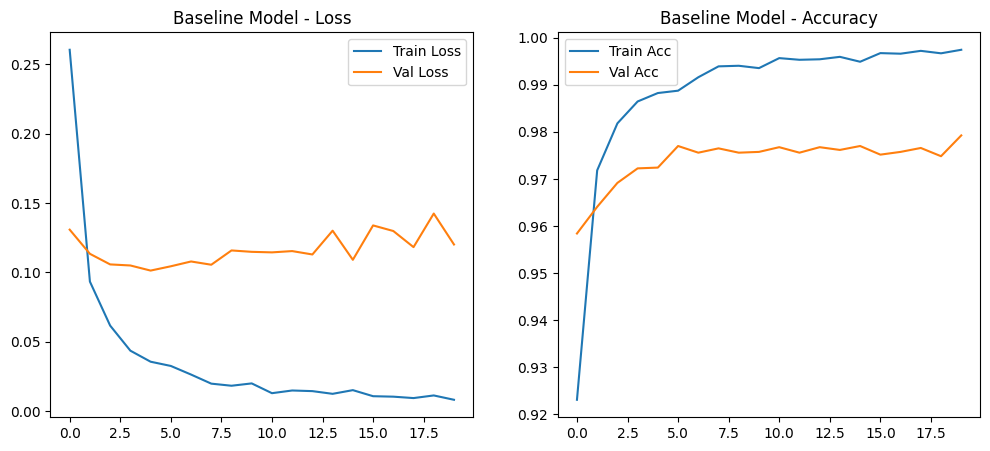

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()

plot_history(history_baseline, "Baseline Model")

Applying dropout

In [ ]:
# function to build dropout model
def build_dropout_model():
  model = keras.Sequential([
      layers.Dense(512, activation="relu", input_shape=(28 * 28,)),
      layers.Dropout(0.2),
      layers.Dense(256, activation="relu"),
      layers.Dropout(0.2),
      layers.Dense(128, activation="relu"),
      layers.Dropout(0.2),
      layers.Dense(64, activation="relu"),
      layers.Dense(10, activation="softmax")
  ])

  return model

In [ ]:
dropout_model = build_dropout_model()

In [ ]:
# compiling model
dropout_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# training model
history_dropout = dropout_model.fit(x_train, y_train, epochs = 20, batch_size= 128, validation_split = 0.2, verbose = 1)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8867 - loss: 0.3691 - val_accuracy: 0.9628 - val_loss: 0.1264
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9585 - loss: 0.1394 - val_accuracy: 0.9674 - val_loss: 0.1033
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9698 - loss: 0.1011 - val_accuracy: 0.9725 - val_loss: 0.0952
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.0829 - val_accuracy: 0.9753 - val_loss: 0.0919
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9795 - loss: 0.0660 - val_accuracy: 0.9770 - val_loss: 0.0908
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9834 - loss: 0.0556 - val_accuracy: 0.9755 - val_loss: 0.0923
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9839 - loss: 0.0522 - val_accuracy: 0.9793 - val_loss: 0.0827
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9861 - loss: 0.0452 - val_accuracy: 0.

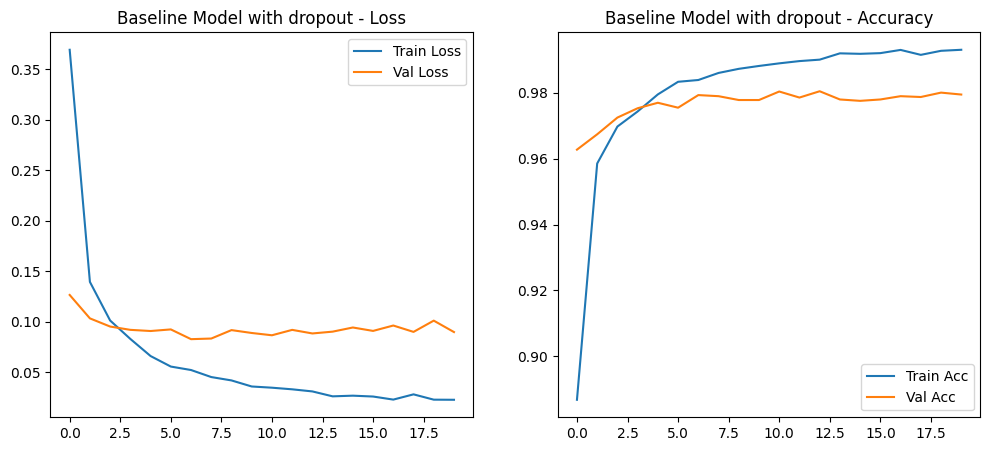

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()

plot_history(history_dropout, "Baseline Model with dropout")

L2 regularization

In [ ]:
# function to build model with L2 regularization
def build_L2_model():
  model = keras.Sequential([
      layers.Dense(512, activation= 'relu', input_shape=(28 * 28,), kernel_regularizer=regularizers.l2(0.001)),
      layers.Dense(256, activation= 'relu', kernel_regularizer=regularizers.l2(0.001)),
      layers.Dense(128, activation= 'relu', kernel_regularizer=regularizers.l2(0.001)),
      layers.Dense(64, activation= 'relu', kernel_regularizer=regularizers.l2(0.001)),
      layers.Dense(10, activation= 'softmax')
  ])

  return model

In [ ]:
L2_model = build_L2_model()

In [ ]:
# comipling model
L2_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# training model
history_L2 = L2_model.fit(
    x_train, y_train,
    epochs = 20,
    batch_size = 128,
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9114 - loss: 0.8851 - val_accuracy: 0.9572 - val_loss: 0.5411
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9597 - loss: 0.4571 - val_accuracy: 0.9649 - val_loss: 0.3855
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9680 - loss: 0.3442 - val_accuracy: 0.9646 - val_loss: 0.3264
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9728 - loss: 0.2870 - val_accuracy: 0.9680 - val_loss: 0.2859
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9754 - loss: 0.2551 - val_accuracy: 0.9693 - val_loss: 0.2617
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9788 - loss: 0.2316 - val_accuracy: 0.9711 - val_loss: 0.2461
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9790 - loss: 0.2149 - val_accuracy: 0.9706 - val_loss: 0.2388
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9809 - loss: 0.2049 - val_accuracy: 0.

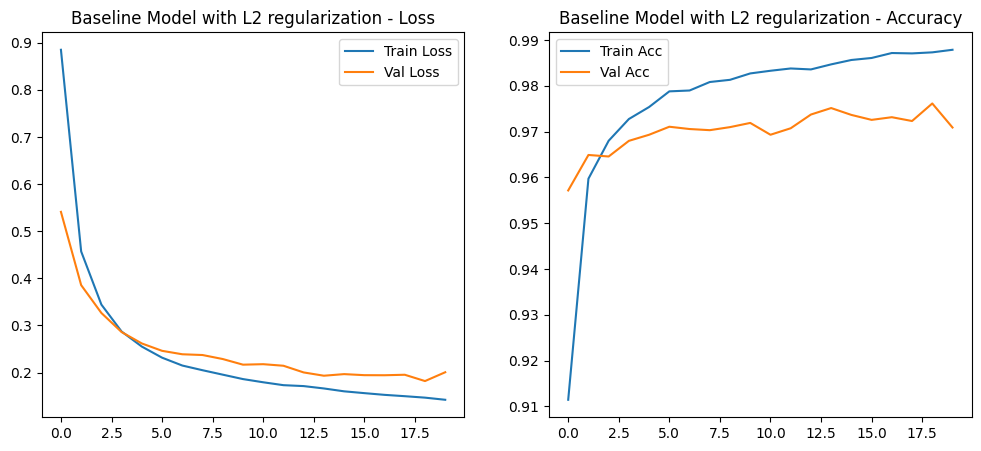

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()

plot_history(history_L2, "Baseline Model with L2 regularization")

Batch Normalization

In [ ]:
# function to build model with batch normalization
def build_BN_model():
  model = keras.Sequential([
      layers.Dense(512, input_shape=(28 * 28,)),
      layers.BatchNormalization(),
      layers.Activation('relu'),

      layers.Dense(256),
      layers.BatchNormalization(),
      layers.Activation('relu'),

      layers.Dense(128),
      layers.BatchNormalization(),
      layers.Activation('relu'),

      layers.Dense(64),
      layers.BatchNormalization(),
      layers.Activation('relu'),


      layers.Dense(10, activation='softmax')
  ])

  return model

In [ ]:
BN_model = build_BN_model()

In [ ]:
# compile model
BN_model.compile(
    optimizer= 'adam',
    loss= 'categorical_crossentropy',
    metrics= ['accuracy']
)

In [ ]:
# training model
history_BN = BN_model.fit(x_train, y_train, validation_split=0.2, epochs = 20, batch_size = 128, verbose = 1)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9371 - loss: 0.2333 - val_accuracy: 0.9633 - val_loss: 0.1228
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9783 - loss: 0.0728 - val_accuracy: 0.9697 - val_loss: 0.1046
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9899 - loss: 0.0366 - val_accuracy: 0.9733 - val_loss: 0.0926
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9939 - loss: 0.0227 - val_accuracy: 0.9737 - val_loss: 0.0914
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9935 - loss: 0.0222 - val_accuracy: 0.9724 - val_loss: 0.1088
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9934 - loss: 0.0192 - val_accuracy: 0.9697 - val_loss: 0.1182
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9934 - loss: 0.0210 - val_accuracy: 0.9763 - val_loss: 0.0931
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9958 - loss: 0.0129 - val_accuracy: 0.

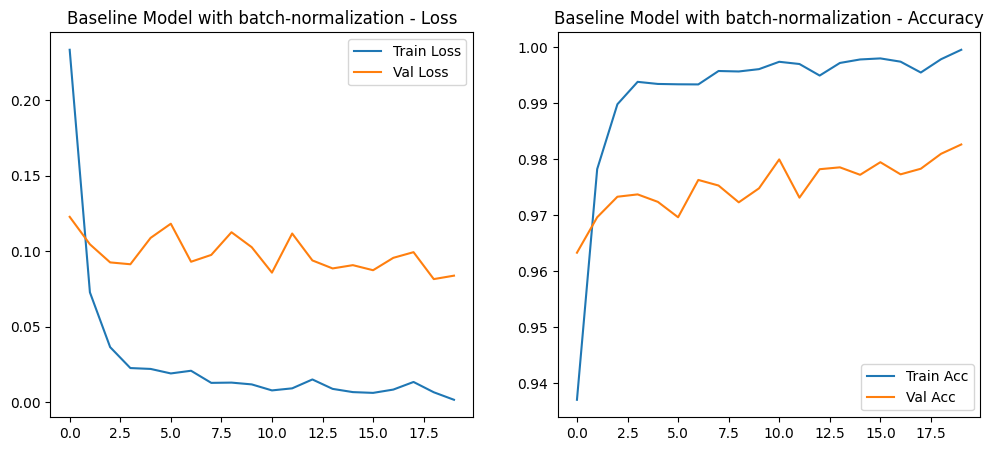

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()

plot_history(history_BN, "Baseline Model with batch-normalization")

In [ ]:
print("Baseline Val Accuracy:", history_baseline.history['val_accuracy'][-1])
print("Dropout Val Accuracy:", history_dropout.history['val_accuracy'][-1])
print("L2 Val Accuracy:", history_L2.history['val_accuracy'][-1])
print("BatchNorm Val Accuracy:", history_BN.history['val_accuracy'][-1])

Baseline Val Accuracy: 0.9792500138282776
Dropout Val Accuracy: 0.9794999957084656
L2 Val Accuracy: 0.9709166884422302
BatchNorm Val Accuracy: 0.9826666712760925
